### This example shows how to use the continuous-wave (cw) `spdc.py` functions to generate second order moments. These are valid for *arbitrary dispersion* and can account for distributed loss. 

In the CW limit, the second order moments are defined as $N_{S/I}(\omega,\omega') = \langle a^{\dagger}_{S/I}(\omega)a_{S/I}(\omega')\rangle \delta(\omega-\omega')  $ and $M(\omega,\omega') = \langle a_{S}(\omega)a_{I}(\omega) \rangle \delta(\omega-\omega')$ and in the discretized case $\delta(\omega-\omega')\approx \delta_{i,j}/\Delta \omega$. The functions output the second order moments without this $1/\Delta \omega$ factor. Effectively, we are considering the second order moments of renormalized operators $\tilde{a}_{\mu}(\omega_{i}) = a_{\mu}(\omega_{i})\sqrt{\Delta \omega}$ which obey the same equations of motion. As such, the generated moment $N_{S}(\omega) \equiv N_{S}(\omega,\omega)\cdot \Delta \omega $ represents the mean photon number on a band centered at frequency $\bar{\omega}_{S}+\omega$ with bandwidth $\Delta \omega$.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from NeedALight.spdc import Scw, Scw_dist   

#### Lossless nonlinear region

We begin by considering a lossless nonlinear region in the cw-limit. In this case, we can use both the `Scw` and `Scw_dist` functions. `Scw` outputs the moments in matrix form which is ammenable to using the update rules (see `example_updates.ipynb` noteook) whereas `Scw_dist` outputs vectors. For the dispersion relations, we construct data which represents a dispersion engineered Type-II squeezer where we have group-velocity matching and group-velocity-dispersion cancellation. Furthermore, we assume that at the central frequencies $\bar{k}_P = \bar{k}_S+ \bar{k}_I$ as such, the pump mode makes no appearence in this note and the phase-mismatch is $-\Delta k(\omega,\omega) = k_{S}(\omega)+k_{I}(-\omega)$. Note that for the idler we define the dispersion relation as $k_{I}(\omega)$.

In [3]:
#Parameters for calculations
N = 301  # Number of frequency values
l = 1.0  # amplification region length
z_list = np.linspace(0,l,1001) # spatial grid for Scw_dist function

#Dispersions
v = 0.1  #velocity of all modes
b = 3    #group-velocity dispersion
ts =0.09   #signal cubic term
ti =0.07   #idler cubic term 
#Frequency values
wi = -10
wf = 10
w = np.linspace(wi, wf, N)
dw = np.abs(w[1]-w[0])
#Dispersion relations
ks = w/v+b*w**2 + ts*w**3
ki = w/v-b*w**2 + ti*w**3


#Interaction strength
Np = 1.72e-3 # Number of pump photons: Vary this to modify gain values
gamma = np.sqrt(Np)/np.sqrt(2 * np.pi * v**3)

First we show the phase-mismatch. We include two sets of horizontal lines which correspond to the values at which the phase-matching function $(\Phi = \text{sinc}(\Delta k(\omega)l/2))$ reaches its first zero for two values of the interaction strength.

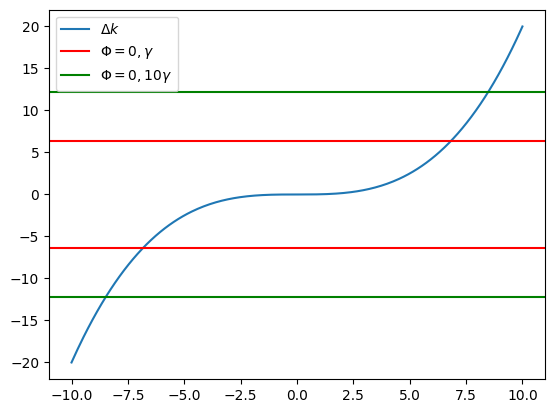

In [4]:
#Since we need ki(-w), we need to flip ki(w)
plt.plot(w, ks+np.flip(ki), label = r"$\Delta k$")
plt.axhline(np.sqrt((2 * np.pi / l) ** 2 + 4 * (gamma) ** 2), color="r",label=r"$\Phi = 0,\gamma$")
plt.axhline(-np.sqrt((2 * np.pi / l) ** 2 + 4 * (gamma) ** 2), color="r")
plt.axhline(np.sqrt((2 * np.pi / l) ** 2 + 4 * (10 * gamma) ** 2),color="g",label=r"$\Phi = 0,10\gamma$")
plt.axhline(-np.sqrt((2 * np.pi / l) ** 2 + 4 * (10 * gamma) ** 2),color="g")
plt.legend()
plt.show()

These horizontal lines help us understand why higher levels of gain lead to broader spectra.

Next we generate the second order moments using both methods. There is a small sublety when converting the matrix outputs of `Scw` into vectors: We need to flip the anti-diagonal $M$ moment properly. Since the signal and idler spectra are the same for the lossless case, we only consider the signal mode.

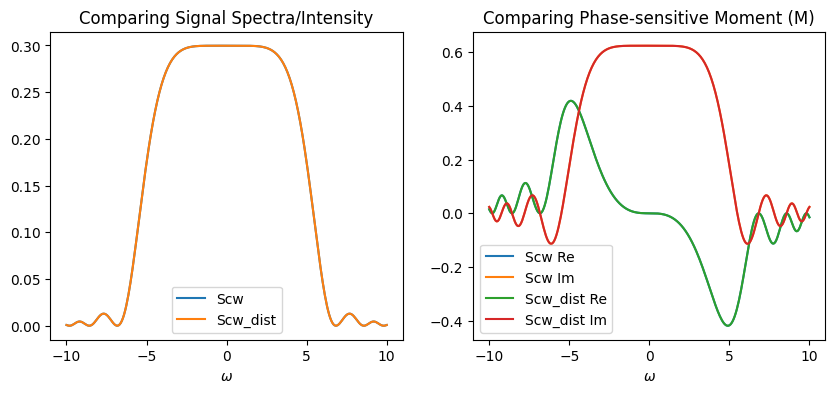

Are the second order moments from both methods the same? (Nums, Numi, M): (True, True, True)


In [5]:
#Generating the different moments
_T, _J, M, Nums, Numi = Scw(ks, ki, gamma, l)
Nums_d, Numi_d, M_d, _Nb, _Mb= Scw_dist(ks, ki, 0, 0, gamma,[0,0],l) #Since lossless, no need to input spatial grid

#Converting matrix outputs to vectors
Nums = np.diag(Nums)
Numi = np.diag(Numi)
M = np.diag(np.fliplr(M)) #Need to l-r flip to obtain proper M vector

#figure comparing all moments

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(w, Nums, label='Scw')
axs[0].plot(w, Nums_d, label='Scw_dist')
axs[0].set_xlabel(r"$\omega$")
axs[0].set_title('Comparing Signal Spectra/Intensity')
axs[0].legend()

axs[1].plot(w, M.real, label='Scw Re')
axs[1].plot(w, M.imag, label='Scw Im')
axs[1].plot(w, M_d.real, label='Scw_dist Re')
axs[1].plot(w, M_d.imag, label='Scw_dist Im')
axs[1].set_xlabel(r"$\omega$")
axs[1].set_title('Comparing Phase-sensitive Moment (M)')
axs[1].legend()

plt.show()

print(f"Are the second order moments from both methods the same? (Nums, Numi, M): {np.allclose(Nums, Nums_d), np.allclose(Numi, Numi_d), np.allclose(M, M_d)}")

### Lossy nonlinear region

Next we consider the case where distributed loss is present. We consider idler-only, frequency-dependent, loss. We consider two absorption events centered at different frequencies with different decay rates ($\kappa$) and spread. We show all second order moments for two different levels of interaction strength. For the peak level of loss, we choose the decay rates such that if treated as beamsplitter loss, the transmision rate would be $\eta = e^{-\kappa L}$. We normalize all moments such that the peak value is unity.

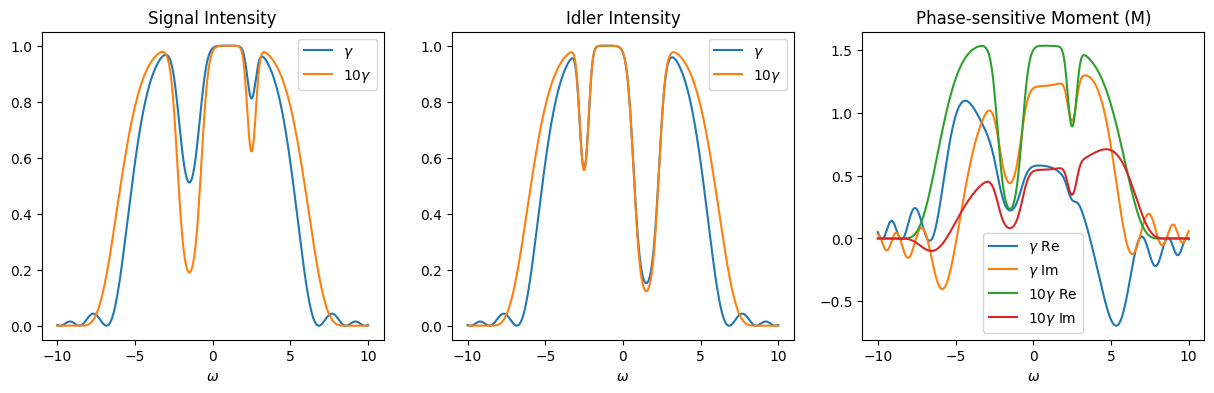

In [7]:
#Absorption
w1 = -2.5     # peak position 1
sig1 = 0.25      # spread 1
str1 = 30/100 # level of absorption.

w2 = 1.5     # peak position 2
sig2 = 0.5     # spread 2
str2 = 1/100 # level of absorption.

kappa_1 = -np.log(str1) * np.exp(-((w - w1) ** 2) / (2 * (sig1) ** 2)) / l
kappa_2 = -np.log(str2) * np.exp(-((w - w2) ** 2) / (2 * (sig2) ** 2)) / l
kappa_I = kappa_1 + kappa_2

#Generating moments
Nums_loss, Numi_loss, M_loss, _Nb, _Mb= Scw_dist(ks, ki, 0, kappa_I, gamma,z_list,l)
Nums_loss2, Numi_loss2, M_loss2, _Nb, _Mb= Scw_dist(ks, ki, 0, kappa_I, 10*gamma,z_list,l)

#Normalizing
Nums_loss = Nums_loss/np.amax(Nums_loss)
Numi_loss = Numi_loss/np.amax(Numi_loss)  
M_loss = M_loss/np.amax(M_loss) 

Nums_loss2 = Nums_loss2/np.amax(Nums_loss2)
Numi_loss2 = Numi_loss2/np.amax(Numi_loss2)  
M_loss2 = M_loss2/np.amax(M_loss2)

#Figure

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(w, Nums_loss, label=r'$\gamma$')
axs[0].plot(w, Nums_loss2, label=r'$10\gamma$')
axs[0].set_xlabel(r"$\omega$")
axs[0].set_title('Signal Intensity')
axs[0].legend()

axs[1].plot(w, Numi_loss, label=r'$\gamma$')
axs[1].plot(w, Numi_loss2, label=r'$10\gamma$')
axs[1].set_xlabel(r"$\omega$")
axs[1].set_title('Idler Intensity')
axs[1].legend()

axs[2].plot(w, M_loss.real, label=r'$\gamma$ Re')
axs[2].plot(w, M_loss.imag, label=r'$\gamma$ Im')
axs[2].plot(w, M_loss2.real, label=r'$10\gamma$ Re')
axs[2].plot(w, M_loss2.imag, label=r'$10\gamma$ Im')
axs[2].set_xlabel(r"$\omega$")
axs[2].set_title('Phase-sensitive Moment (M)')
axs[2].legend()

plt.show()

We see that distributed idler-only loss affects the signal mode. The level of overall absorption depends on the interaction strength. Higher levels of gain lead to more pronounced absorption peaks with the effect being more drastic on the signal intensity. As we increase the interaction strength we also observe some spectral broadening. This can be explained by the shift in values for which the phase-matching function reaches its first zero.